In [ ]:
from datetime import datetime
import sys
import os
import time
# Set the current directory and utilities path
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utilities')

# Change the working directory to the notebook's directory
os.chdir(current_dir)

# Modify the module search path to include utilities directory
sys.path.insert(0, utilities_dir)

import importlib
import analytical_solution_functions
import bem_solution_functions
import plotting_functions

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.patches import ConnectionPatch
from bem_solution_functions import Circle_n

/tmp/ipykernel_47357/2231704828.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


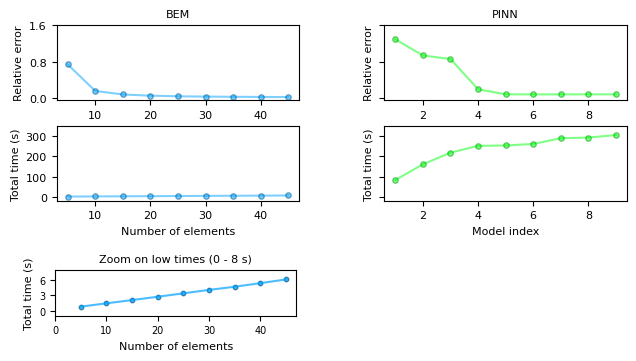

In [33]:
 

# --- Load data ---
bem_df = pd.read_csv("data/bem_accuracy_vs_n.csv")
pinn_df = pd.read_csv("data/pinn_accuracy_vs_architecture.csv")

# --- BEM ---
bem_df = bem_df.sort_values("n")

n_bem = bem_df["n"].values
e_bem = bem_df["relative_error"].values

time_bem = (
    bem_df["evaluation_time_sec"].values +
    bem_df["assembly_solution_time_sec"].values
)

# --- PINN ---
pinn_df = pinn_df.copy()
pinn_df["model_id"] = np.arange(1, len(pinn_df) + 1)

model_id = pinn_df["model_id"].values
e_pinn = pinn_df["mean_relative_error"].values

time_pinn = (
    pinn_df["training_time_sec"].values +
    pinn_df["mean_eval_time_sec"].values
)

# --- Figure (2x2) ---
fig, axes = plt.subplots(2, 2, figsize=(6.2, 2.3), sharey='row')

# =========================
# TOP LEFT: BEM - Error
# =========================
axes[0, 0].plot(n_bem, e_bem, color="#00a2ff", zorder=1, alpha=0.5)
axes[0, 0].scatter(n_bem, e_bem, s=15, color="#00a2ff", edgecolor="#00578a", zorder=2, alpha=0.5)
axes[0, 0].set_title("BEM", size=8)
#axes[0, 0].set_xlabel("Integration points")
#axes[0, 0].set_ylim(-0.05, 0.9)
#axes[0, 0].set_yticks([0, 0.4, 0.8])
axes[0, 0].set_ylabel("Relative error")

# =========================
# TOP RIGHT: PINN - Error
# =========================
axes[0, 1].plot(model_id, e_pinn, color="#00ff0d", zorder=1, alpha=0.5)
axes[0, 1].scatter(model_id, e_pinn, s=15, color="#00ff0d", edgecolor="#009908", zorder=2, alpha=0.5)
axes[0, 1].set_title("PINN", size=8)
#axes[0, 1].set_xlabel("Model index")
axes[0, 1].set_ylabel("Relative error")
axes[0, 1].set_ylim(-0.05, 1.5)
axes[0, 1].set_yticks([0, 0.8, 1.6])

# =========================
# BOTTOM LEFT: BEM - Time
# =========================
axes[1, 0].plot(n_bem, time_bem, color="#00a2ff", zorder=1, alpha=0.5)
axes[1, 0].scatter(n_bem, time_bem, s=15, color="#00a2ff", edgecolor="#00578a", zorder=2, alpha=0.5)
axes[1, 0].set_xlabel("Number of elements")
axes[1, 0].set_ylabel("Total time (s)")

# Get position of the BEM time subplot
pos = axes[1, 0].get_position()

# Create a new axis BELOW it
ax_zoom = fig.add_axes([
    pos.x0 - 0.05,            # same left
    pos.y0 - 0.45,     # move down (adjust this!)
    pos.width + 0.037,         # same width
    0.20               # height of zoom panel
])

# Plot same data
ax_zoom.plot(n_bem, time_bem, color="#00a2ff", alpha=0.7)
ax_zoom.scatter(n_bem, time_bem, s=10, color="#00a2ff", edgecolor="#00578a", alpha=0.7)

# Zoom range
ax_zoom.set_ylim(-1, 8)
ax_zoom.set_yticks([0, 3, 6])
ax_zoom.set_xticks([0, 10, 20, 30, 40])

# Labels
ax_zoom.set_title(f"Zoom on low times (0 - 8 s)", fontsize=8)
ax_zoom.set_xlabel("Number of elements", fontsize=8)
ax_zoom.set_ylabel("Total time (s)", fontsize=8)

# Small ticks
ax_zoom.tick_params(labelsize=7)

 
# =========================
# BOTTOM RIGHT: PINN - Time
# =========================
axes[1, 1].plot(model_id, time_pinn, color="#00ff0d", zorder=1, alpha=0.5)
axes[1, 1].scatter(model_id, time_pinn, s=15, color="#00ff0d", edgecolor="#009908", zorder=2, alpha=0.5)
axes[1, 1].set_ylim(-20, 350)
axes[1, 1].set_yticks([0, 100, 200, 300])
axes[1, 1].set_xlabel("Model index")
axes[1, 1].set_ylabel("Total time (s)")

plt.tight_layout()
fig.subplots_adjust(wspace=0.35, hspace=0.35)
plt.savefig("figures/bem_pinn_convergence.pdf", dpi=300, bbox_inches='tight')
plt.savefig("figures/bem_pinn_convergence.svg", dpi=300, bbox_inches='tight')
plt.show()

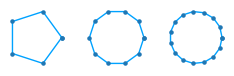

In [ ]:
 
# Valores de n
n_values = [5, 10, 15]

# Crear figura con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(2.5, 0.6))

for ax, n in zip(axes, n_values):
    
    # Obtener vértices
    aVertex, aElement = Circle_n(n=n, radius=np.pi/4)
    aVertex = np.array(aVertex)

    # Coordenadas
    x = aVertex[:, 0]
    y = aVertex[:, 1]

    # Cerrar polígono
    x_closed = np.append(x, x[0])
    y_closed = np.append(y, y[0])

    # Plot
    ax.scatter(x_closed, y_closed, color='#1f77b4', zorder=2, s=5)
    ax.plot(x_closed, y_closed, color="#00a2ff", zorder=1, linewidth=1)

    ax.set_aspect('equal')
    ax.axis('off')

# Ajustar espacios
plt.tight_layout()
plt.savefig("figures/circle_collocation_points.svg", dpi=300, bbox_inches='tight')
plt.show()